# Raw-audio dataset figures

Band energy, PCA of timbre features, and mean STFT spectra for `training`, A1 (`flow`), A2 (`flow-2`), B1 (`thinkpad`), B2 (`thinkpad-2`). Waveform + STFT only — no CQT. Style follows `article-workflow/references/figures.md`.

Reads `results/raw_features.pkl` and `results/mean_spectra.npz` when present; otherwise extracts a 40-per-class training sample plus every eval clip.

## Config

In [23]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.frameon': False,
    'hatch.linewidth': 0.55,
    'axes.linewidth': 0.8,
    'figure.dpi': 110,
})

REPO = Path('/home/seya/code/chord-detection')
HERE = REPO / 'training' / 'notebooks' / 'raw-audio'
RESULTS = HERE / 'results'
RESULTS.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(HERE))

from analyze_raw_audio import (  # noqa: E402
    DATASETS,
    HOP,
    LABELS,
    N_FFT,
    ORDER,
    SR_TARGET,
    TIMBRE_COLS,
    cohens_d,
    extract_dataset,
    list_files,
    load_audio,
)

KEYBOARD = {
    'training': 'Techno T-9890i',
    'flow': 'Techno T-9890i',
    'thinkpad': 'Techno T-9890i',
    'flow-2': 'Yamaha PSR-S910',
    'thinkpad-2': 'Yamaha PSR-S910',
}
KEYBOARD_PAIRS = [
    ('flow', 'flow-2', 'keyboard @ Flow (A1 vs A2)'),
    ('thinkpad', 'thinkpad-2', 'keyboard @ ThinkPad (B1 vs B2)'),
]

# Distinct colors, all solid. Hatch still marks keyboard on the bars.
STYLE = {
    'training': dict(
        face='white', edge='#111111', hatch='',
        color='#111111', marker='o', label='training',
    ),
    'flow': dict(
        face='#d6e3f0', edge='#1f4e79', hatch='///',
        color='#1f4e79', marker='o', label='A1',
    ),
    'flow-2': dict(
        face='#c5ebe4', edge='#0b7a72', hatch='xxx',
        color='#0b7a72', marker='^', label='A2',
    ),
    'thinkpad': dict(
        face='#f6d3b0', edge='#c45c26', hatch='///',
        color='#c45c26', marker='s', label='B1',
    ),
    'thinkpad-2': dict(
        face='#efd0da', edge='#7a1840', hatch='xxx',
        color='#7a1840', marker='D', label='B2',
    ),
}

CACHE_FEAT = RESULTS / 'raw_features.pkl'
CACHE_SPEC = RESULTS / 'mean_spectra.npz'
FORCE_REEXTRACT = False
TRAIN_PER_CLASS = 40
WORKERS = 12
SEED = 0


def export_fig(fig, name):
    fig.savefig(RESULTS / f'{name}.png', dpi=160)
    display(fig)
    plt.close(fig)


def style_axes(ax):
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=':', linewidth=0.4, color='0.75')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:.4g}')


def keyboard_contrast(frame, cols):
    rows = []
    for a, b, name in KEYBOARD_PAIRS:
        aa = frame[frame.dataset == a]
        bb = frame[frame.dataset == b]
        for col in cols:
            va = aa[col].to_numpy(dtype=float)
            vb = bb[col].to_numpy(dtype=float)
            rows.append(
                {
                    'contrast': name,
                    'feature': col,
                    'techno_mean': float(np.nanmean(va)),
                    'yamaha_mean': float(np.nanmean(vb)),
                    'delta': float(np.nanmean(va) - np.nanmean(vb)),
                    'cohens_d': cohens_d(va, vb),
                }
            )
    return pd.DataFrame(rows)


def dataset_table(frame, cols):
    tab = (
        frame.groupby('dataset', sort=False)[list(cols)]
        .agg(['mean', 'std', 'median'])
        .reindex(ORDER)
    )
    tab.index = [LABELS[i] for i in tab.index]
    tab.index.name = 'label'
    return tab


def boxplot_datasets(ax, frame, col, ylabel, ylim=None, tick_labels=None, title=None, flier_size=2.5):
    data = [frame.loc[frame.dataset == ds, col].dropna().to_numpy() for ds in ORDER]
    bp = ax.boxplot(
        data,
        tick_labels=tick_labels or [STYLE[d]['label'] for d in ORDER],
        patch_artist=True,
        widths=0.64,
        medianprops={'color': 'black', 'linewidth': 1.1},
        whiskerprops={'color': '0.25', 'linewidth': 0.8},
        capprops={'color': '0.25', 'linewidth': 0.8},
        flierprops={
            'marker': '.', 'markersize': flier_size,
            'markerfacecolor': '0.35', 'markeredgecolor': 'none',
        },
    )
    for box, ds in zip(bp['boxes'], ORDER):
        st = STYLE[ds]
        box.set(facecolor=st['face'], edgecolor=st['edge'], linewidth=0.9, hatch=st['hatch'])
    if ylabel:
        ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, loc='center', fontweight='bold', pad=6)
    if ylim is not None:
        ax.set_ylim(*ylim)
    style_axes(ax)


config = pd.DataFrame(
    [
        ('cache_features', CACHE_FEAT),
        ('cache_spectra', CACHE_SPEC),
        ('cache_exists', CACHE_FEAT.exists() and CACHE_SPEC.exists()),
        ('force_reextract', FORCE_REEXTRACT),
        ('train_per_class', TRAIN_PER_CLASS),
        ('workers', WORKERS),
    ],
    columns=['key', 'value'],
)
display(config)

,key,value
0,cache_features,/home/seya/code/chord-detection/training/noteb...
1,cache_spectra,/home/seya/code/chord-detection/training/noteb...
2,cache_exists,True
3,force_reextract,False
4,train_per_class,40
5,workers,12


## Load cache

In [8]:
if not FORCE_REEXTRACT and CACHE_FEAT.exists() and CACHE_SPEC.exists():
    df = pd.read_pickle(CACHE_FEAT)
    spec_npz = np.load(CACHE_SPEC)
    spec_map = {k: spec_npz[k] for k in ORDER}
    freqs = spec_npz['freqs'] if 'freqs' in spec_npz.files else np.fft.rfftfreq(N_FFT, 1.0 / SR_TARGET)
    source = 'cache'
else:
    frames = []
    spec_map = {}
    for ds in DATASETS:
        cap = TRAIN_PER_CLASS if ds['id'] == 'training' else None
        frame, spec = extract_dataset(ds, cap, SEED, WORKERS)
        frames.append(frame)
        spec_map[ds['id']] = spec
    df = pd.concat(frames, ignore_index=True)
    df.to_pickle(CACHE_FEAT)
    df.to_csv(RESULTS / 'raw_features.csv', index=False)
    freqs = np.fft.rfftfreq(N_FFT, 1.0 / SR_TARGET)
    np.savez(CACHE_SPEC, **spec_map, freqs=freqs)
    source = 'extracted'

ok = df[df.ok & ~df.silent.fillna(False)].copy()
inventory = pd.DataFrame(
    {
        'source': source,
        'label': [LABELS[d] for d in ORDER],
        'dataset': ORDER,
        'n': [int((ok.dataset == d).sum()) for d in ORDER],
        'n_silent': [int(((df.dataset == d) & df.silent.fillna(False)).sum()) for d in ORDER],
        'n_channels': [int(ok.loc[ok.dataset == d, 'n_channels'].mode().iloc[0]) for d in ORDER],
    }
)
display(inventory)

SUMMARY_COLS = [
    'duration_s', 'rms_db', 'peak_db', 'zcr', 'crest',
    'centroid_hz', 'decay_s', 'onset_s',
    'band_low', 'band_fund', 'band_mid', 'band_presence',
]
summary = dataset_table(ok, SUMMARY_COLS)
display(summary)
summary.to_csv(RESULTS / 'table-summary.csv')

,source,label,dataset,n,n_silent,n_channels
0,cache,training,training,1439,1,1
1,cache,A1,flow,1440,0,2
2,cache,A2,flow-2,1440,0,2
3,cache,B1,thinkpad,1440,0,2
4,cache,B2,thinkpad-2,1440,0,2


duration_s               rms_db              peak_db                  zcr                  crest               centroid_hz              decay_s                  onset_s                  \
               mean    std median   mean   std median    mean   std median    mean      std  median  mean    std median        mean   std median    mean     std median      mean      std median   
label                                                                                                                                                                                               
training      2.436 0.1058  2.413 -20.92 1.043 -20.91  -2.085 1.089 -1.676 0.03598 0.005001 0.03571 8.792 0.9162  8.716       698.4   208  685.8  0.4291 0.07511 0.4267   0.03093  0.01338  0.032   
A1            2.438 0.1076   2.46 -19.57   1.5  -19.6  -2.009 1.413 -1.767 0.03424 0.006303 0.03325 7.593 0.8151  7.473       404.7  61.1  394.7  0.3554 0.05742  0.352  0.001067 0.003747      0   
A2             2.44 0.1068   2.46 -22.62 1.482 -22.35  -6.321 1.387 -6.344 0.02556 0.005092 0.02448 6.575 0.7798  6.508         416 89.35  374.9  0.6842  0.1022 0.6827         0        0      0   
B1            2.449 0.1067   2.46 -26.62 1.552  -26.9  -9.074 1.512  -9.27  0.0388 0.006954 0.03829 7.585  0.873  7.488       449.8 80.13  446.5  0.3883  0.0726 0.3733         0        0      0   
B2            2.516  0.214   2.46  -26.8 1.498 -26.53  -10.47 1.466 -10.53 0.02548 0.005233 0.02491 6.595 0.7731  6.539       410.5    86  376.4  0.6911 0.09857 0.6933 0.0001111 0.004216      0   

         band_low                band_fund                band_mid                 band_presence                      
             mean     std median      mean     std median     mean     std  median          mean       std    median  
label                                                                                                                 
training    0.129 0.06073 0.1261    0.5152 0.07709 0.5085   0.3514 0.07261  0.3481      0.004321  0.003092  0.002862  
A1          0.483  0.1441  0.519    0.4686  0.1399 0.4332  0.04494 0.02146 0.03967     0.0001974  0.000119 0.0001694  
A2         0.3114  0.1115 0.3179    0.5628   0.104 0.5445   0.1232 0.05062  0.1121     0.0002878 0.0002226 0.0002127  
B1         0.1931 0.07625 0.1935    0.7379 0.08903 0.7308  0.05862 0.02459 0.05999     0.0007431  0.000722 0.0003579  
B2         0.3096  0.1028 0.3185    0.5599 0.09379 0.5577   0.1274 0.04881  0.1158     0.0003466 0.0004317 0.0002732

## Mean spectra

Energy-normalized mean log STFT. Panel B is Yamaha minus Techno on the same microphone.

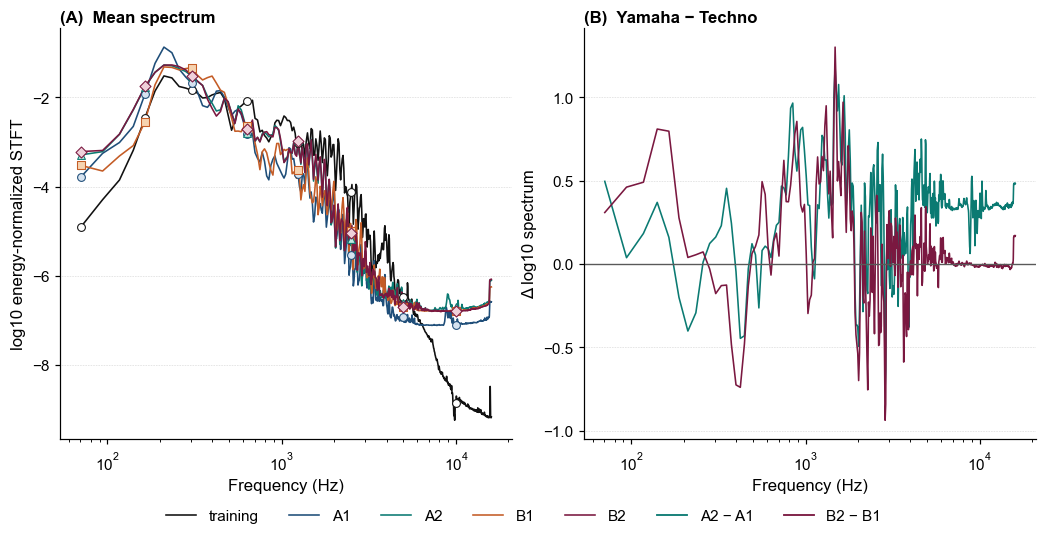

,training,A1,A2,B1,B2,A2 − A1,B2 − B1
Hz,,,,,,,
80,-4.907,-3.785,-3.289,-3.523,-3.214,0.4963,0.3092
160,-2.456,-1.925,-1.765,-2.551,-1.754,0.1604,0.797
315,-1.84,-1.682,-1.52,-1.331,-1.508,0.162,-0.1769
630,-2.077,-2.828,-2.789,-2.64,-2.706,0.03897,-0.06589
1250,-3.019,-3.723,-2.951,-3.619,-2.973,0.7718,0.6457
2500,-4.115,-5.537,-5.178,-4.991,-5.05,0.3592,-0.0597
5000,-6.466,-6.926,-6.618,-6.699,-6.692,0.3084,0.007339
1e+04,-8.844,-7.102,-6.694,-6.788,-6.799,0.4079,-0.01077


In [9]:
band = (freqs >= 50.0) & (freqs <= 16000.0)
mark_hz = np.array([80.0, 160.0, 315.0, 630.0, 1250.0, 2500.0, 5000.0, 10000.0])

fig, axes = plt.subplots(1, 2, figsize=(9.4, 4.8), layout='constrained')

ax = axes[0]
handles = []
for ds in ORDER:
    st = STYLE[ds]
    y = spec_map[ds][band]
    (line,) = ax.plot(
        freqs[band], y,
        color=st['color'], linestyle='-', linewidth=1.05,
        label=st['label'], zorder=3,
    )
    mi = np.array([int(np.argmin(np.abs(freqs[band] - hz))) for hz in mark_hz])
    ax.scatter(
        freqs[band][mi], y[mi],
        s=26, marker=st['marker'],
        facecolors=st['face'], edgecolors=st['color'],
        linewidths=0.7, zorder=4,
    )
    handles.append(line)
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('log10 energy-normalized STFT')
ax.set_title('(A)  Mean spectrum', loc='left', fontweight='bold', fontsize=11, pad=4)
style_axes(ax)

ax = axes[1]
ax.plot(
    freqs[band], spec_map['flow-2'][band] - spec_map['flow'][band],
    color=STYLE['flow-2']['color'], linestyle='-', linewidth=1.05,
    label='A2 − A1',
)
ax.plot(
    freqs[band], spec_map['thinkpad-2'][band] - spec_map['thinkpad'][band],
    color=STYLE['thinkpad-2']['color'], linestyle='-', linewidth=1.05,
    label='B2 − B1',
)
ax.axhline(0.0, color='0.35', linewidth=0.9)
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Δ log10 spectrum')
ax.set_title('(B)  Yamaha − Techno', loc='left', fontweight='bold', fontsize=11, pad=4)
style_axes(ax)

resid_handles = [
    Line2D([0], [0], color=STYLE['flow-2']['color'], ls='-', lw=1.2, label='A2 − A1'),
    Line2D([0], [0], color=STYLE['thinkpad-2']['color'], ls='-', lw=1.2, label='B2 − B1'),
]
fig.legend(
    handles=handles + resid_handles,
    loc='outside lower center',
    ncol=7,
    frameon=False,
    fontsize=10,
)
export_fig(fig, 'fig-mean-spectra')

spec_at = pd.DataFrame(
    {LABELS[ds]: spec_map[ds][band][mi] for ds in ORDER},
    index=pd.Index(mark_hz, name='Hz'),
)
spec_at['A2 − A1'] = spec_at['A2'] - spec_at['A1']
spec_at['B2 − B1'] = spec_at['B2'] - spec_at['B1']
display(spec_at)
spec_at.to_csv(RESULTS / 'table-mean-spectra.csv')

## Band energy

Linear-energy fraction per band, 20 Hz–6 kHz. The 6–16 kHz air band is dropped: it holds well under 0.02% of the energy on every set. Hatch marks the keyboard (Techno `///`, Yamaha `xxx`).

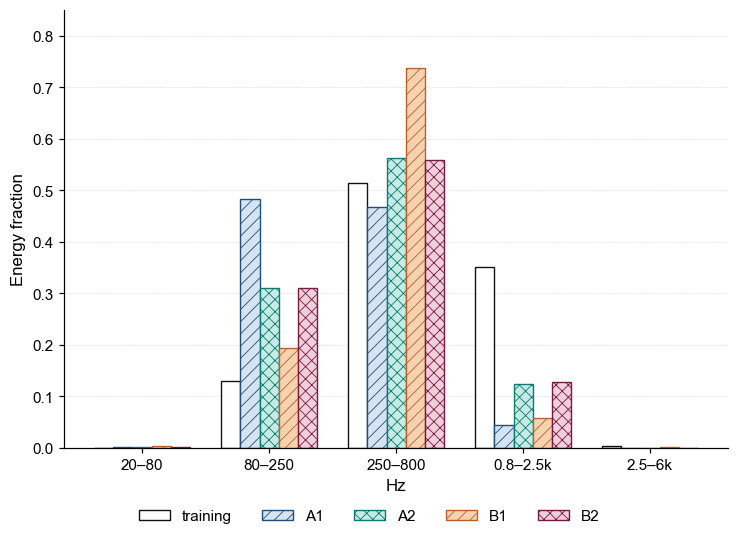

,20–80,80–250,250–800,0.8–2.5k,2.5–6k
label,,,,,
training,3.073e-05,0.129,0.5152,0.3514,0.004321
A1,0.001289,0.483,0.4686,0.04494,0.0001974
A2,0.001383,0.3114,0.5628,0.1232,0.0002878
B1,0.004492,0.1931,0.7379,0.05862,0.0007431
B2,0.001899,0.3096,0.5599,0.1274,0.0003466


In [10]:
band_cols = ['band_rumble', 'band_low', 'band_fund', 'band_mid', 'band_presence']
band_labels = ['20–80', '80–250', '250–800', '0.8–2.5k', '2.5–6k']
means = ok.groupby('dataset')[band_cols].mean().reindex(ORDER)

fig, ax = plt.subplots(figsize=(6.6, 4.8), layout='constrained')
x = np.arange(len(band_cols))
width = 0.15
handles = []
for i, ds in enumerate(ORDER):
    st = STYLE[ds]
    bars = ax.bar(
        x + (i - 2) * width,
        means.loc[ds].to_numpy(),
        width=width,
        facecolor=st['face'],
        edgecolor=st['edge'],
        linewidth=0.9,
        hatch=st['hatch'],
        label=st['label'],
    )
    handles.append(bars)

ax.set_xticks(x, band_labels)
ax.set_ylabel('Energy fraction')
ax.set_xlabel('Hz')
ax.set_ylim(0, 0.85)
style_axes(ax)

fig.legend(
    handles=handles,
    loc='outside lower center',
    ncol=5,
    frameon=False,
    fontsize=10,
)
export_fig(fig, 'fig-band-energy')

band_table = means.copy()
band_table.index = [LABELS[i] for i in band_table.index]
band_table.index.name = 'label'
band_table.columns = band_labels
display(band_table)
band_table.to_csv(RESULTS / 'table-band-energy.csv')

## PCA timbre

First two principal components of the level-invariant spectral / MFCC / envelope feature set (no RMS). Outlined markers: circle = Techno, triangle / diamond = Yamaha.

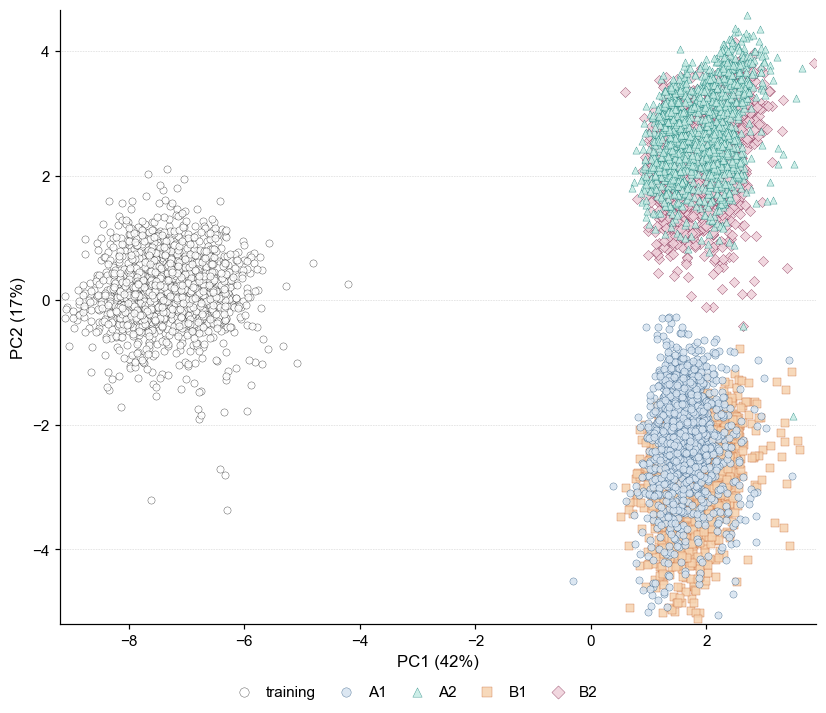

,component,variance_frac,variance_pct
0,PC1,0.419,41.9
1,PC2,0.1701,17.01


PC1           PC2       
           mean    std   mean    std
label                               
training -7.357 0.7878 0.1505 0.6246
A1        1.635 0.3648  -2.19 0.8147
A2         1.92  0.537  2.685 0.7157
B1        1.833 0.4431 -2.892 0.6995
B2        1.964 0.4754  2.246 0.7588

In [11]:
timbre = [c for c in TIMBRE_COLS if c in ok.columns]
X = ok[timbre].to_numpy()
mask = np.isfinite(X).all(axis=1)
frame = ok.loc[mask]
X = StandardScaler().fit_transform(X[mask])
pca = PCA(n_components=2, random_state=0)
xy = pca.fit_transform(X)
var = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(7.4, 6.4), layout='constrained')
handles = []
# Draw denser clusters first so the smaller Yamaha / training marks stay visible.
for ds in ('thinkpad', 'flow', 'thinkpad-2', 'flow-2', 'training'):
    st = STYLE[ds]
    m = frame.dataset.to_numpy() == ds
    sc = ax.scatter(
        xy[m, 0], xy[m, 1],
        s=22,
        facecolors=st['face'],
        edgecolors=st['color'],
        linewidths=0.25,
        marker=st['marker'],
        alpha=0.85,
        label=st['label'],
    )
    handles.append(sc)

# One near-silent training take sits at PC1 ≈ −22 and would empty the frame.
ax.set_xlim(np.percentile(xy[:, 0], 0.4) - 0.5, np.percentile(xy[:, 0], 99.8) + 0.5)
ax.set_ylim(np.percentile(xy[:, 1], 0.4) - 0.5, np.percentile(xy[:, 1], 99.8) + 0.5)
ax.set_xlabel(f'PC1 ({100 * var[0]:.0f}%)')
ax.set_ylabel(f'PC2 ({100 * var[1]:.0f}%)')
style_axes(ax)
fig.legend(
    handles=[handles[i] for i in (4, 1, 3, 0, 2)],
    loc='outside lower center',
    ncol=5,
    frameon=False,
    fontsize=10,
    markerscale=1.3,
    handletextpad=0.4,
    columnspacing=1.0,
)
export_fig(fig, 'fig-pca-timbre')

pca_var = pd.DataFrame(
    {'component': ['PC1', 'PC2'], 'variance_frac': var, 'variance_pct': 100 * var}
)
pca_centers = (
    pd.DataFrame({'dataset': frame.dataset.to_numpy(), 'PC1': xy[:, 0], 'PC2': xy[:, 1]})
    .groupby('dataset', sort=False)[['PC1', 'PC2']]
    .agg(['mean', 'std'])
    .reindex(ORDER)
)
pca_centers.index = [LABELS[i] for i in pca_centers.index]
pca_centers.index.name = 'label'
display(pca_var)
display(pca_centers)
pca_var.to_csv(RESULTS / 'table-pca-variance.csv', index=False)
pca_centers.to_csv(RESULTS / 'table-pca-centers.csv')

## Zero-crossing rate

ZCR is higher when the waveform flips more often (brighter / noisier). Training, A1, and B1 are the Techno T-9890i; A2 and B2 are the Yamaha PSR-S910. A keyboard effect should line up A1 with B1 and A2 with B2, not with the microphone.

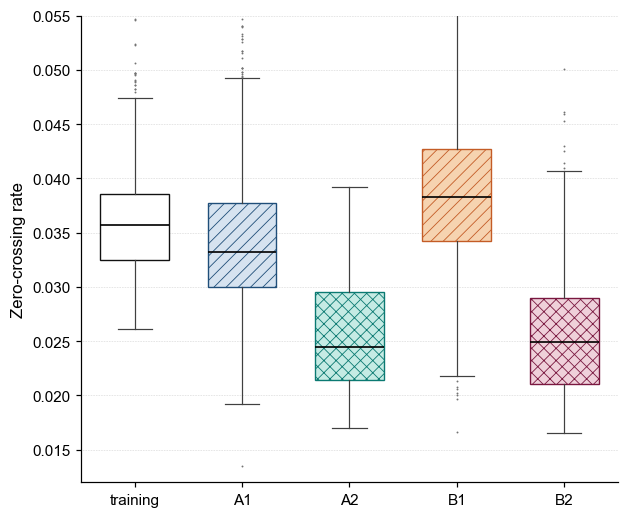

zcr                 
            mean      std  median
label                            
training 0.03598 0.005001 0.03571
A1       0.03424 0.006303 0.03325
A2       0.02556 0.005092 0.02448
B1        0.0388 0.006954 0.03829
B2       0.02548 0.005233 0.02491

,contrast,feature,techno_mean,yamaha_mean,delta,cohens_d
0,keyboard @ Flow (A1 vs A2),zcr,0.03424,0.02556,0.008687,1.516
1,keyboard @ ThinkPad (B1 vs B2),zcr,0.0388,0.02548,0.01331,2.163


In [15]:
fig, ax = plt.subplots(figsize=(5.6, 4.6), layout='constrained')
boxplot_datasets(ax, ok, 'zcr', 'Zero-crossing rate', ylim=(0.012, 0.055))
export_fig(fig, 'fig-zcr')

zcr_tbl = dataset_table(ok, ['zcr'])
zcr_kb = keyboard_contrast(ok, ['zcr'])
display(zcr_tbl)
display(zcr_kb)
zcr_tbl.to_csv(RESULTS / 'table-zcr.csv')
zcr_kb.to_csv(RESULTS / 'table-zcr-keyboard.csv', index=False)

## Decay time

Time after the envelope peak until the level falls to $1/e$. Same Techno / Yamaha grouping as ZCR. Yamaha should sit together on both mics if this is the instrument, not the laptop.

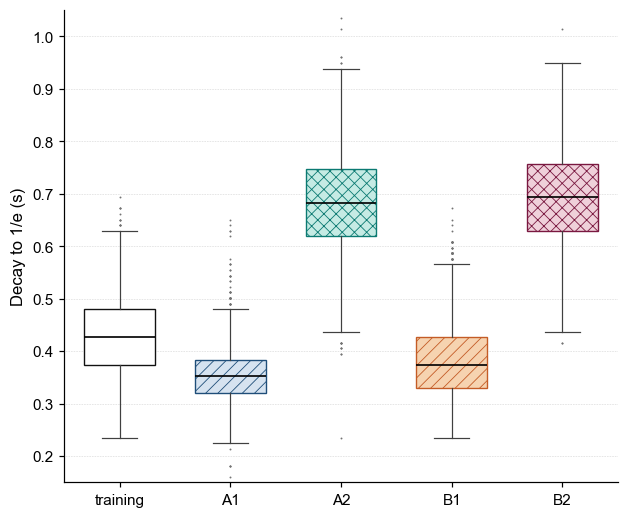

decay_s               
            mean     std median
label                          
training  0.4291 0.07511 0.4267
A1        0.3554 0.05742  0.352
A2        0.6842  0.1022 0.6827
B1        0.3883  0.0726 0.3733
B2        0.6911 0.09857 0.6933

,contrast,feature,techno_mean,yamaha_mean,delta,cohens_d
0,keyboard @ Flow (A1 vs A2),decay_s,0.3554,0.6842,-0.3287,-3.967
1,keyboard @ ThinkPad (B1 vs B2),decay_s,0.3883,0.6911,-0.3028,-3.499


In [16]:
fig, ax = plt.subplots(figsize=(5.6, 4.6), layout='constrained')
boxplot_datasets(ax, ok, 'decay_s', 'Decay to 1/e (s)', ylim=(0.15, 1.05))
export_fig(fig, 'fig-decay')

decay_tbl = dataset_table(ok, ['decay_s'])
decay_kb = keyboard_contrast(ok, ['decay_s'])
display(decay_tbl)
display(decay_kb)
decay_tbl.to_csv(RESULTS / 'table-decay.csv')
decay_kb.to_csv(RESULTS / 'table-decay-keyboard.csv', index=False)

## Temporal centroid

Center of mass of the RMS envelope as a fraction of clip length. Later means more energy in the tail — the same Yamaha sustain that shows up in decay, independent of overall loudness.

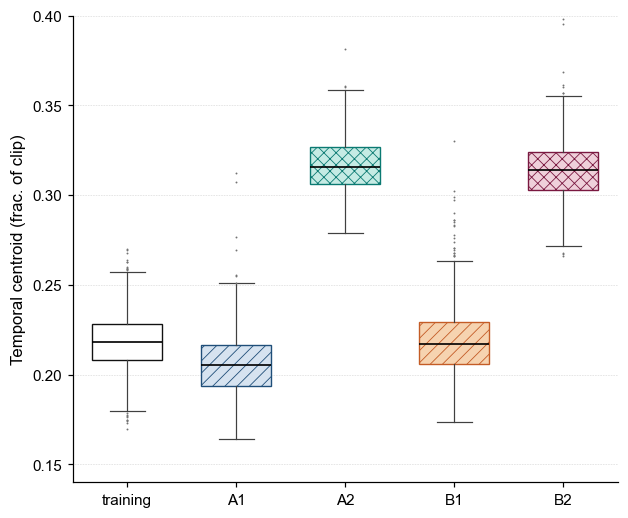

temporal_centroid               
                      mean     std median
label                                    
training             0.218 0.01523 0.2184
A1                  0.2051 0.01679 0.2051
A2                  0.3168  0.0146 0.3158
B1                  0.2182 0.01811 0.2172
B2                  0.3136 0.01643 0.3138

,contrast,feature,techno_mean,yamaha_mean,delta,cohens_d
0,keyboard @ Flow (A1 vs A2),temporal_centroid,0.2051,0.3168,-0.1116,-7.096
1,keyboard @ ThinkPad (B1 vs B2),temporal_centroid,0.2182,0.3136,-0.09536,-5.516


In [19]:
fig, ax = plt.subplots(figsize=(5.6, 4.6), layout='constrained')
boxplot_datasets(ax, ok, 'temporal_centroid', 'Temporal centroid (frac. of clip)', ylim=(0.14, 0.40))
export_fig(fig, 'fig-temporal-centroid')

tc_tbl = dataset_table(ok, ['temporal_centroid'])
tc_kb = keyboard_contrast(ok, ['temporal_centroid'])
display(tc_tbl)
display(tc_kb)
tc_tbl.to_csv(RESULTS / 'table-temporal-centroid.csv')
tc_kb.to_csv(RESULTS / 'table-temporal-centroid-keyboard.csv', index=False)

## Crest factor

Peak amplitude divided by RMS. A more impulsive attack (Techno) raises crest; a rounder Yamaha attack lowers it. Same Techno / Yamaha grouping as decay and ZCR.

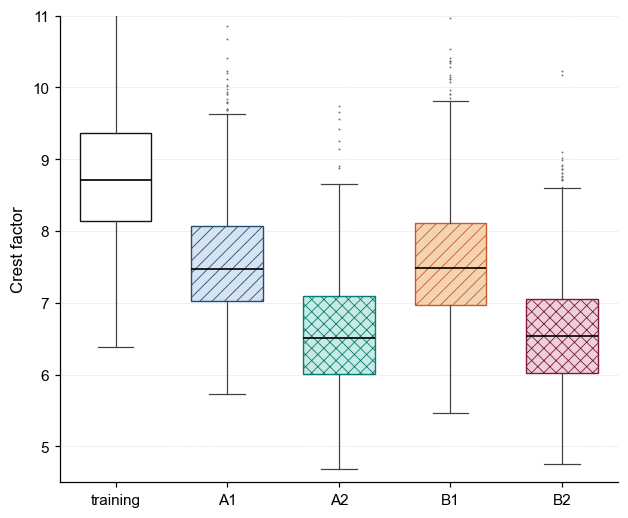

crest              
          mean    std median
label                       
training 8.792 0.9162  8.716
A1       7.593 0.8151  7.473
A2       6.575 0.7798  6.508
B1       7.585  0.873  7.488
B2       6.595 0.7731  6.539

,contrast,feature,techno_mean,yamaha_mean,delta,cohens_d
0,keyboard @ Flow (A1 vs A2),crest,7.593,6.575,1.018,1.276
1,keyboard @ ThinkPad (B1 vs B2),crest,7.585,6.595,0.9901,1.201


In [20]:
fig, ax = plt.subplots(figsize=(5.6, 4.6), layout='constrained')
boxplot_datasets(ax, ok, 'crest', 'Crest factor', ylim=(4.5, 11))
export_fig(fig, 'fig-crest')

crest_tbl = dataset_table(ok, ['crest'])
crest_kb = keyboard_contrast(ok, ['crest'])
display(crest_tbl)
display(crest_kb)
crest_tbl.to_csv(RESULTS / 'table-crest.csv')
crest_kb.to_csv(RESULTS / 'table-crest-keyboard.csv', index=False)

## Keyboard four-way

ZCR, decay, temporal centroid, and crest on one figure. Training / A1 / B1 are Techno; A2 / B2 are Yamaha.

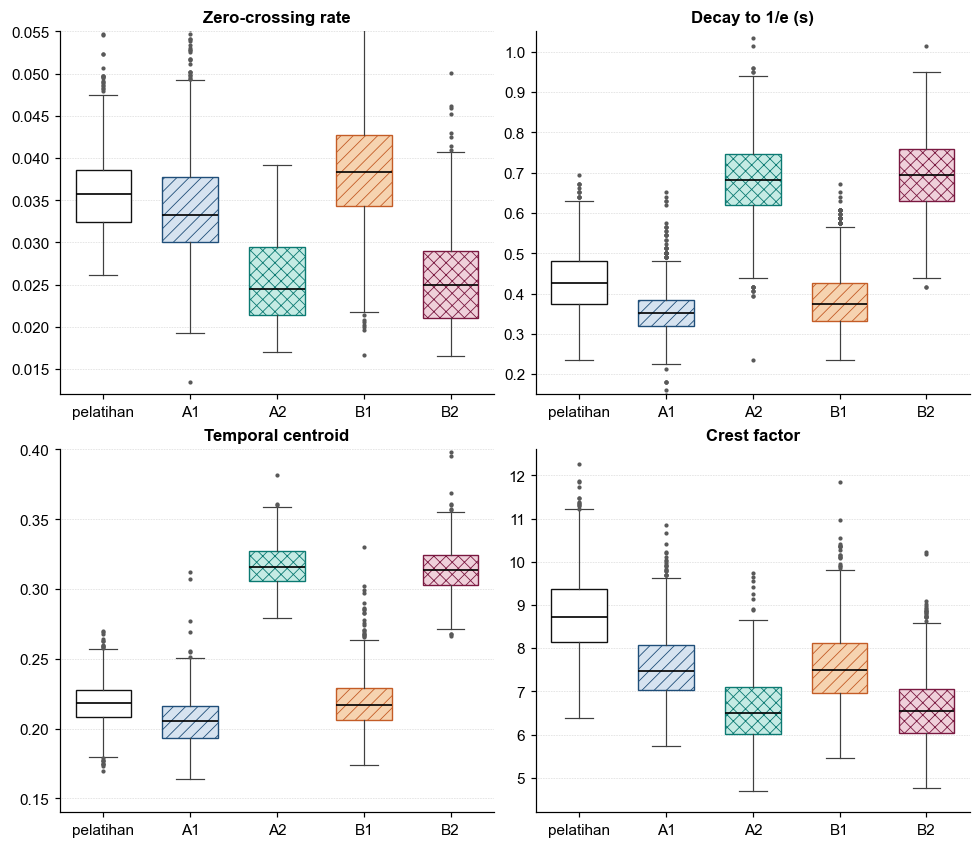

zcr                  decay_s                temporal_centroid                crest              
             mean      std  median    mean     std median              mean     std median  mean    std median
label                                                                                                         
pelatihan 0.03598 0.005001 0.03571  0.4291 0.07511 0.4267             0.218 0.01523 0.2184 8.792 0.9162  8.716
A1        0.03424 0.006303 0.03325  0.3554 0.05742  0.352            0.2051 0.01679 0.2051 7.593 0.8151  7.473
A2        0.02556 0.005092 0.02448  0.6842  0.1022 0.6827            0.3168  0.0146 0.3158 6.575 0.7798  6.508
B1         0.0388 0.006954 0.03829  0.3883  0.0726 0.3733            0.2182 0.01811 0.2172 7.585  0.873  7.488
B2        0.02548 0.005233 0.02491  0.6911 0.09857 0.6933            0.3136 0.01643 0.3138 6.595 0.7731  6.539

,contrast,feature,techno_mean,yamaha_mean,delta,cohens_d
0,keyboard @ Flow (A1 vs A2),zcr,0.03424,0.02556,0.008687,1.516
1,keyboard @ Flow (A1 vs A2),decay_s,0.3554,0.6842,-0.3287,-3.967
2,keyboard @ Flow (A1 vs A2),temporal_centroid,0.2051,0.3168,-0.1116,-7.096
3,keyboard @ Flow (A1 vs A2),crest,7.593,6.575,1.018,1.276
4,keyboard @ ThinkPad (B1 vs B2),zcr,0.0388,0.02548,0.01331,2.163
5,keyboard @ ThinkPad (B1 vs B2),decay_s,0.3883,0.6911,-0.3028,-3.499
6,keyboard @ ThinkPad (B1 vs B2),temporal_centroid,0.2182,0.3136,-0.09536,-5.516
7,keyboard @ ThinkPad (B1 vs B2),crest,7.585,6.595,0.9901,1.201


In [24]:
KB4 = ['zcr', 'decay_s', 'temporal_centroid', 'crest']
TICKS = ['pelatihan', 'A1', 'A2', 'B1', 'B2']

fig, axes = plt.subplots(2, 2, figsize=(8.8, 7.6), layout='constrained')
boxplot_datasets(
    axes[0, 0], ok, 'zcr', ylabel='', ylim=(0.012, 0.055),
    tick_labels=TICKS, title='Zero-crossing rate', flier_size=5.5,
)
boxplot_datasets(
    axes[0, 1], ok, 'decay_s', ylabel='', ylim=(0.15, 1.05),
    tick_labels=TICKS, title='Decay to 1/e (s)', flier_size=5.5,
)
boxplot_datasets(
    axes[1, 0], ok, 'temporal_centroid', ylabel='', ylim=(0.14, 0.40),
    tick_labels=TICKS, title='Temporal centroid', flier_size=5.5,
)
boxplot_datasets(
    axes[1, 1], ok, 'crest', ylabel='', ylim=(4.2, 12.6),
    tick_labels=TICKS, title='Crest factor', flier_size=5.5,
)
export_fig(fig, 'fig-keyboard-fourway')

kb4_tbl = dataset_table(ok, KB4)
kb4_tbl.index = TICKS
kb4_tbl.index.name = 'label'
kb4_contrast = keyboard_contrast(ok, KB4)
display(kb4_tbl)
display(kb4_contrast)
kb4_tbl.to_csv(RESULTS / 'table-keyboard-fourway.csv')
kb4_contrast.to_csv(RESULTS / 'table-keyboard-fourway-contrast.csv', index=False)

## Remaining keyboard-stable scalars

`log_flatness` (tonal vs noisy) and mid-band energy. Temporal centroid and crest are in their own sections above.

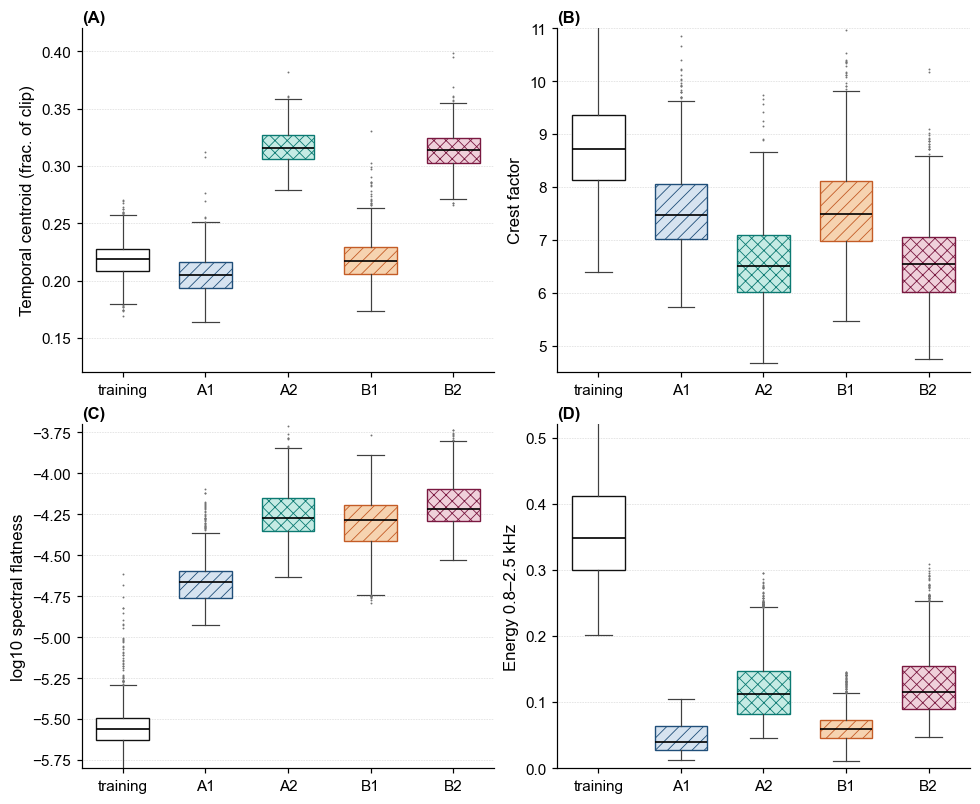

temporal_centroid                crest               log_flatness               band_mid                
                      mean     std median  mean    std median         mean    std median     mean     std  median
label                                                                                                            
training             0.218 0.01523 0.2184 8.792 0.9162  8.716        -5.55 0.1279 -5.563   0.3514 0.07261  0.3481
A1                  0.2051 0.01679 0.2051 7.593 0.8151  7.473       -4.664 0.1353 -4.663  0.04494 0.02146 0.03967
A2                  0.3168  0.0146 0.3158 6.575 0.7798  6.508       -4.248 0.1518 -4.273   0.1232 0.05062  0.1121
B1                  0.2182 0.01811 0.2172 7.585  0.873  7.488       -4.312 0.1728 -4.283  0.05862 0.02459 0.05999
B2                  0.3136 0.01643 0.3138 6.595 0.7731  6.539       -4.196  0.144 -4.218   0.1274 0.04881  0.1158

,contrast,feature,techno_mean,yamaha_mean,delta,cohens_d
0,keyboard @ Flow (A1 vs A2),zcr,0.03424,0.02556,0.008687,1.516
1,keyboard @ Flow (A1 vs A2),decay_s,0.3554,0.6842,-0.3287,-3.967
2,keyboard @ Flow (A1 vs A2),temporal_centroid,0.2051,0.3168,-0.1116,-7.096
3,keyboard @ Flow (A1 vs A2),crest,7.593,6.575,1.018,1.276
4,keyboard @ Flow (A1 vs A2),log_flatness,-4.664,-4.248,-0.416,-2.893
5,keyboard @ Flow (A1 vs A2),band_mid,0.04494,0.1232,-0.07824,-2.012
6,keyboard @ ThinkPad (B1 vs B2),zcr,0.0388,0.02548,0.01331,2.163
7,keyboard @ ThinkPad (B1 vs B2),decay_s,0.3883,0.6911,-0.3028,-3.499
8,keyboard @ ThinkPad (B1 vs B2),temporal_centroid,0.2182,0.3136,-0.09536,-5.516
9,keyboard @ ThinkPad (B1 vs B2),crest,7.585,6.595,0.9901,1.201


In [17]:
KB_REST = ['log_flatness', 'band_mid']

fig, axes = plt.subplots(1, 2, figsize=(8.8, 4.6), layout='constrained')
boxplot_datasets(axes[0], ok, 'log_flatness', 'log10 spectral flatness', ylim=(-5.8, -3.7))
boxplot_datasets(axes[1], ok, 'band_mid', 'Energy 0.8–2.5 kHz', ylim=(0, 0.52))
axes[0].set_title('(A)', loc='left', fontweight='bold', pad=4)
axes[1].set_title('(B)', loc='left', fontweight='bold', pad=4)
export_fig(fig, 'fig-keyboard-scalars')

kb_rest = dataset_table(ok, KB_REST)
kb_contrast = keyboard_contrast(ok, ['zcr', 'decay_s', 'temporal_centroid', 'crest'] + KB_REST)
display(kb_rest)
display(kb_contrast)
kb_rest.to_csv(RESULTS / 'table-keyboard-scalars.csv')
kb_contrast.to_csv(RESULTS / 'table-keyboard-contrast.csv', index=False)

## Mean peak-normalized envelope

Average RMS envelope, peak-normalized so level drops out. If decay is the instrument, Yamaha (A2, B2) should stay up longer on both laptops. 8 takes per class (288 clips / dataset).

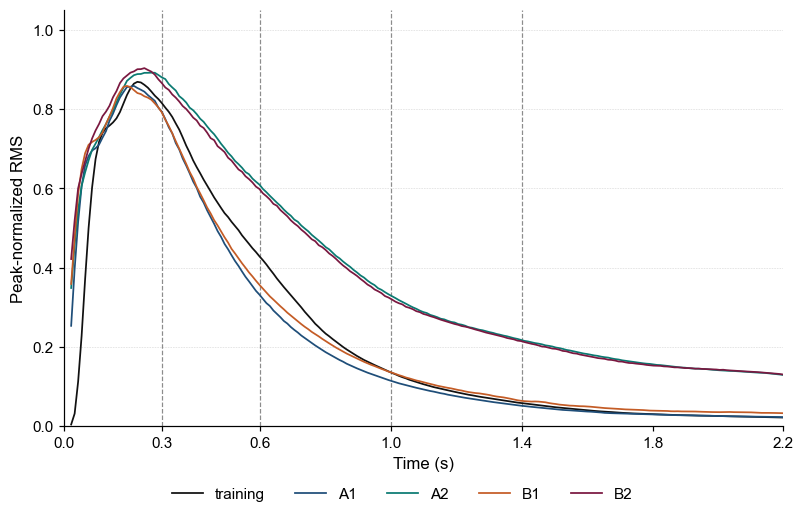

,source,clips_per_dataset
0,cache,288


,training,A1,A2,B1,B2,A2 − A1,B2 − B1
t_s,,,,,,,
0.3,0.8141,0.7911,0.8798,0.7898,0.8646,0.08869,0.0748
0.6,0.4258,0.3289,0.6067,0.3538,0.5956,0.2778,0.2418
1,0.1347,0.1137,0.3289,0.1351,0.3205,0.2153,0.1854
1.4,0.05741,0.05067,0.2165,0.06315,0.2136,0.1658,0.1504


In [22]:
from numpy.lib.stride_tricks import sliding_window_view

T_MAX = 2.20
ENV_HOP = HOP
GRID = np.arange(0.0, T_MAX, ENV_HOP / SR_TARGET)
ENV_PER_CLASS = 8
ENV_CACHE = RESULTS / 'mean_envelopes.npz'


def clip_envelope(path):
    y_st, sr = load_audio(path)
    y = y_st.mean(axis=0) if y_st.shape[0] > 1 else y_st[0]
    if y.size < N_FFT:
        y = np.pad(y, (0, N_FFT - y.size))
    env = np.sqrt(np.mean(sliding_window_view(y, N_FFT)[::ENV_HOP] ** 2, axis=1))
    peak = float(env.max())
    if peak < 1e-8:
        return None
    t = (np.arange(env.size) * ENV_HOP + N_FFT / 2.0) / sr
    return np.interp(GRID, t, env / peak, left=np.nan, right=np.nan)


if ENV_CACHE.exists() and not FORCE_REEXTRACT:
    env_npz = np.load(ENV_CACHE)
    env_mean = {ds: env_npz[ds] for ds in ORDER}
    env_source = 'cache'
else:
    env_mean = {}
    for ds in DATASETS:
        files = list_files(ds['id'], ds['ext'], ENV_PER_CLASS, SEED)
        acc = []
        for p in files:
            env = clip_envelope(p)
            if env is not None:
                acc.append(env)
        env_mean[ds['id']] = np.nanmean(np.stack(acc), axis=0)
        print(ds['id'], len(acc), 'envelopes', flush=True)
    np.savez(ENV_CACHE, **env_mean, t=GRID)
    env_source = 'computed'

ENV_TIMES = (0.3, 0.6, 1.0, 1.4)

fig, ax = plt.subplots(figsize=(7.2, 4.6), layout='constrained')
handles = []
for ds in ORDER:
    st = STYLE[ds]
    (line,) = ax.plot(
        GRID, env_mean[ds],
        color=st['color'], linewidth=1.15, label=st['label'], zorder=3,
    )
    handles.append(line)
for t in ENV_TIMES:
    ax.axvline(t, color='0.55', linewidth=0.8, linestyle='--', zorder=1)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Peak-normalized RMS')
ax.set_xlim(0, T_MAX)
ax.set_ylim(0, 1.05)
ax.set_xticks([0.0, 0.3, 0.6, 1.0, 1.4, 1.8, 2.2])
style_axes(ax)
fig.legend(handles=handles, loc='outside lower center', ncol=5, frameon=False, fontsize=10)
export_fig(fig, 'fig-envelope')

# Envelope leftover at 0.6 s and 1.2 s — a numeric read of the same curve.
env_pts = pd.DataFrame(
    {LABELS[ds]: [float(np.interp(t, GRID, env_mean[ds])) for t in ENV_TIMES] for ds in ORDER},
    index=pd.Index(list(ENV_TIMES), name='t_s'),
)
env_pts['A2 − A1'] = env_pts['A2'] - env_pts['A1']
env_pts['B2 − B1'] = env_pts['B2'] - env_pts['B1']
display(pd.DataFrame([{'source': env_source, 'clips_per_dataset': 36 * ENV_PER_CLASS}]))
display(env_pts)
env_pts.to_csv(RESULTS / 'table-envelope.csv')